# Phase 3-2 v2 — 가중치별 BL 백테스트 평가 (`05a_v2_weighting.ipynb`)

> **목적**: Black-Litterman P 행렬 그룹 내 가중치 (mcap / 1/N eq / Risk Parity rp) 에 따른
>          백테스트 성과 비교. ML 효과의 가중치 robustness 검정.

## 6 시나리오 (3 가중치 × 2 vol input) + 3 baseline

| 가중치 \ vol input | ML (LSTM ensemble) | Trailing (vol_21d) |
|---|---|---|
| **mcap** (Pyo & Lee 2018) | BL_ml_sw_mcap | BL_trailing_mcap |
| **eq** (DeMiguel 2009) | BL_ml_sw_eq | BL_trailing_eq |
| **rp** (Maillard 2010) | BL_ml_sw_rp | BL_trailing_rp |

baseline: EqualWeight, McapWeight, SPY

## 분석 영역

| § | 분석 |
|---|---|
| §2 | Layer 2 — 6 시나리오 + 3 baseline 메트릭 표 (OOS + Hold-out 분리) |
| §3 | 가중치별 누적 수익 + drawdown 시각화 |
| §4 | **ML 효과 분해** (BL_ml_sw_X - BL_trailing_X, X=mcap/eq/rp) — 핵심 분석 |
| §5 | Layer 3 — ML→BL 인과 (가중치별 P 행렬 turnover, hit rate) |
| §6 | Layer 4 — 시기별 분해 (5 시기 × 6 시나리오) |
| §7 | 종합 요약 + 메트릭 JSON 저장 |

## 사전 조건
- ✅ `outputs/03_bl_backtest/returns_BL_*.csv` (9 시나리오)
- ✅ `data/scenario_weights_03_v2.pkl` (9 시나리오 weights_dict)
- ✅ `data/daily_panel.csv`
- ✅ `data/market_data.csv` (SPY)

**05a_v2.ipynb 와의 차별화**:
- 05a_v2: BL_ml_sw_mcap 1 시나리오 단독 평가
- **05a_v2_weighting**: 6 시나리오 (3 가중치 × 2 vol input) 비교, ML 효과 robustness

## §1. 환경 부트스트랩 + 9 시나리오 returns 로드

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings, pickle
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR
import scripts.diagnostics as diag

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '05a_v2_weighting'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

# OOS / Hold-out 기간 (Phase 3-2 v2)
OOS_START, OOS_END = '2010-01-01', '2024-12-31'
HOLD_START, HOLD_END = '2025-01-01', '2025-12-31'

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_v2_weighting


In [2]:
# 9 시나리오 returns 로드
BL_DIR = OUTPUTS_DIR / '03_bl_backtest'

scenarios = [
    'BL_ml_sw_mcap', 'BL_ml_sw_eq', 'BL_ml_sw_rp',
    'BL_trailing_mcap', 'BL_trailing_eq', 'BL_trailing_rp',
    'BL_ml_cs',  # cross-sectional (mcap만)
    'EqualWeight', 'McapWeight', 'SPY',
]

returns_dict = {}
for sc in scenarios:
    p = BL_DIR / f'returns_{sc}.csv'
    if p.exists():
        ret = pd.read_csv(p, index_col=0, parse_dates=True).squeeze()
        if isinstance(ret, pd.DataFrame):
            ret = ret.iloc[:, 0]
        returns_dict[sc] = ret
        print(f'  ✅ {sc}: {len(ret)} 개월, '
              f'{ret.index.min().date()} ~ {ret.index.max().date()}')
    else:
        print(f'  ⚠️ {sc}: 파일 없음 ({p.name})')

print(f'\n총 로드: {len(returns_dict)} / {len(scenarios)} 시나리오')

# 6 시나리오 (가중치 × vol input) — 핵심 비교 대상
SCENARIOS_6 = [
    'BL_ml_sw_mcap', 'BL_ml_sw_eq', 'BL_ml_sw_rp',
    'BL_trailing_mcap', 'BL_trailing_eq', 'BL_trailing_rp',
]
WEIGHTING_LABELS = ['mcap', 'eq', 'rp']
VOL_INPUT_LABELS = ['ml_sw', 'trailing']

# spy_monthly (Layer 2 메트릭에서 SPY 비교 시 사용)
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
_reb_all = market.groupby(market.index.to_period('M')).tail(1).index
oos_dates = _reb_all[(_reb_all >= OOS_START) & (_reb_all <= OOS_END)]
holdout_dates = _reb_all[(_reb_all >= HOLD_START) & (_reb_all <= HOLD_END)]
all_reb_dates = pd.DatetimeIndex(list(oos_dates) + list(holdout_dates))
spy_monthly = market['SPY'].reindex(all_reb_dates, method='ffill').pct_change().dropna()
print(f'\nspy_monthly: {len(spy_monthly)} 개월 (OOS {len(oos_dates)} + hold-out {len(holdout_dates)})')

# weights_dict 로드 (Layer 3 활용)
weights_path = DATA_DIR / 'scenario_weights_03_v2.pkl'
if weights_path.exists():
    with open(weights_path, 'rb') as f:
        weights_pkl = pickle.load(f)
    scenario_weights = weights_pkl.get('scenario_weights', {})
    print(f'\n✅ weights_dict 로드: {len(scenario_weights)} 시나리오')
    print(f'   keys: {list(scenario_weights.keys())}')
else:
    scenario_weights = {}
    print(f'\n⚠️ weights pickle 부재 → §5 Layer 3 skip')

  ✅ BL_ml_sw_mcap: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ BL_ml_sw_eq: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ BL_ml_sw_rp: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ BL_trailing_mcap: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ BL_trailing_eq: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ BL_trailing_rp: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ BL_ml_cs: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ EqualWeight: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ McapWeight: 192 개월, 2010-01-29 ~ 2025-12-31
  ✅ SPY: 191 개월, 2010-02-26 ~ 2025-12-31

총 로드: 10 / 10 시나리오

spy_monthly: 191 개월 (OOS 180 + hold-out 12)

✅ weights_dict 로드: 9 시나리오
   keys: ['BL_ml_sw_mcap', 'BL_ml_sw_eq', 'BL_ml_sw_rp', 'BL_ml_cs', 'BL_trailing_mcap', 'BL_trailing_eq', 'BL_trailing_rp', 'EqualWeight', 'McapWeight']


## §2. Layer 2 — 6 시나리오 + 3 baseline 메트릭 표

각 시나리오별 Sharpe, CAGR, Vol, MDD, CAPM α, IR, Sortino, CVaR, hit_rate 등 단독 평가.
OOS (2010-2024, 180개월) + Hold-out (2025, 12개월) 분리.

In [3]:
# §2. Layer 2 메트릭 표 (6 시나리오 + 3 baseline)
print('=' * 75)
print('  §2. Layer 2 — 6 시나리오 + 3 baseline 메트릭')
print('=' * 75)

KEY_METRICS = ['sharpe', 'cagr', 'ann_vol', 'mdd', 'capm_alpha', 'capm_beta',
               'information_ratio', 'sortino', 'hit_rate', 'cvar_5']

def calc_metrics(rets, name, period_start=None, period_end=None):
    if period_start and period_end:
        rets = rets.loc[period_start:period_end]
    if len(rets) == 0:
        return {k: np.nan for k in KEY_METRICS}
    m = diag.evaluate_portfolio_standalone(
        returns=rets,
        scenario_name=name,
        spy_returns=spy_monthly,
        rf_returns=None,
        weights_dict=None,
    )
    return {k: m.get(k, np.nan) for k in KEY_METRICS}

# 9 시나리오 메트릭 (전체 + OOS + Hold-out)
all_scenarios = [
    'BL_ml_sw_mcap', 'BL_ml_sw_eq', 'BL_ml_sw_rp',
    'BL_trailing_mcap', 'BL_trailing_eq', 'BL_trailing_rp',
    'EqualWeight', 'McapWeight', 'SPY',
]

metrics_full = {}
metrics_oos = {}
metrics_hold = {}
for sc in all_scenarios:
    if sc not in returns_dict:
        continue
    rets = returns_dict[sc]
    metrics_full[sc] = calc_metrics(rets, sc)
    metrics_oos[sc] = calc_metrics(rets, sc + ' (OOS)', OOS_START, OOS_END)
    metrics_hold[sc] = calc_metrics(rets, sc + ' (Hold-out)', HOLD_START, HOLD_END)

mf_df = pd.DataFrame(metrics_full).T.round(3)
mo_df = pd.DataFrame(metrics_oos).T.round(3)
mh_df = pd.DataFrame(metrics_hold).T.round(3)

print()
print('=== 전체 (2010-2025, 192개월) ===')
print(mf_df.to_string())
print()
print('=== OOS (2010-2024, 180개월) ===')
print(mo_df.to_string())
print()
print('=== Hold-out (2025, 12개월) ===')
print(mh_df.to_string())

# 저장
mf_df.to_csv(OUT_DIR / '2_metrics_full.csv')
mo_df.to_csv(OUT_DIR / '2_metrics_oos.csv')
mh_df.to_csv(OUT_DIR / '2_metrics_holdout.csv')
print(f'\n💾 2_metrics_full/oos/holdout.csv')

  §2. Layer 2 — 6 시나리오 + 3 baseline 메트릭

=== 전체 (2010-2025, 192개월) ===
                   sharpe      cagr   ann_vol        mdd  capm_alpha  capm_beta  information_ratio  sortino  hit_rate    cvar_5
BL_ml_sw_mcap    1.082000 12.573000 11.612000 -18.288000   14.404000  -0.131000          -0.102000 1.659000 64.583000 -6.571000
BL_ml_sw_eq      1.140000 12.738000 11.108000 -16.861000   14.255000  -0.112000          -0.097000 1.735000 64.583000 -6.376000
BL_ml_sw_rp      1.135000 12.641000 11.079000 -16.728000   14.178000  -0.114000          -0.103000 1.732000 65.104000 -6.371000
BL_trailing_mcap 1.203000 13.915000 11.427000 -16.709000   15.476000  -0.124000          -0.043000 1.905000 68.750000 -6.491000
BL_trailing_eq   1.161000 12.752000 10.896000 -15.944000   14.287000  -0.116000          -0.099000 1.800000 64.583000 -6.238000
BL_trailing_rp   1.158000 12.712000 10.890000 -16.143000   14.256000  -0.116000          -0.101000 1.791000 64.583000 -6.229000
EqualWeight      0.886000 13.4540

## §3. 가중치별 누적 수익 + Drawdown 시각화

3 가중치 (mcap/eq/rp) × 2 vol input (ml_sw/trailing) = 6 시나리오.
3 baseline (EW, Mcap, SPY) 비교.

  §3. 가중치별 누적 수익 + Drawdown


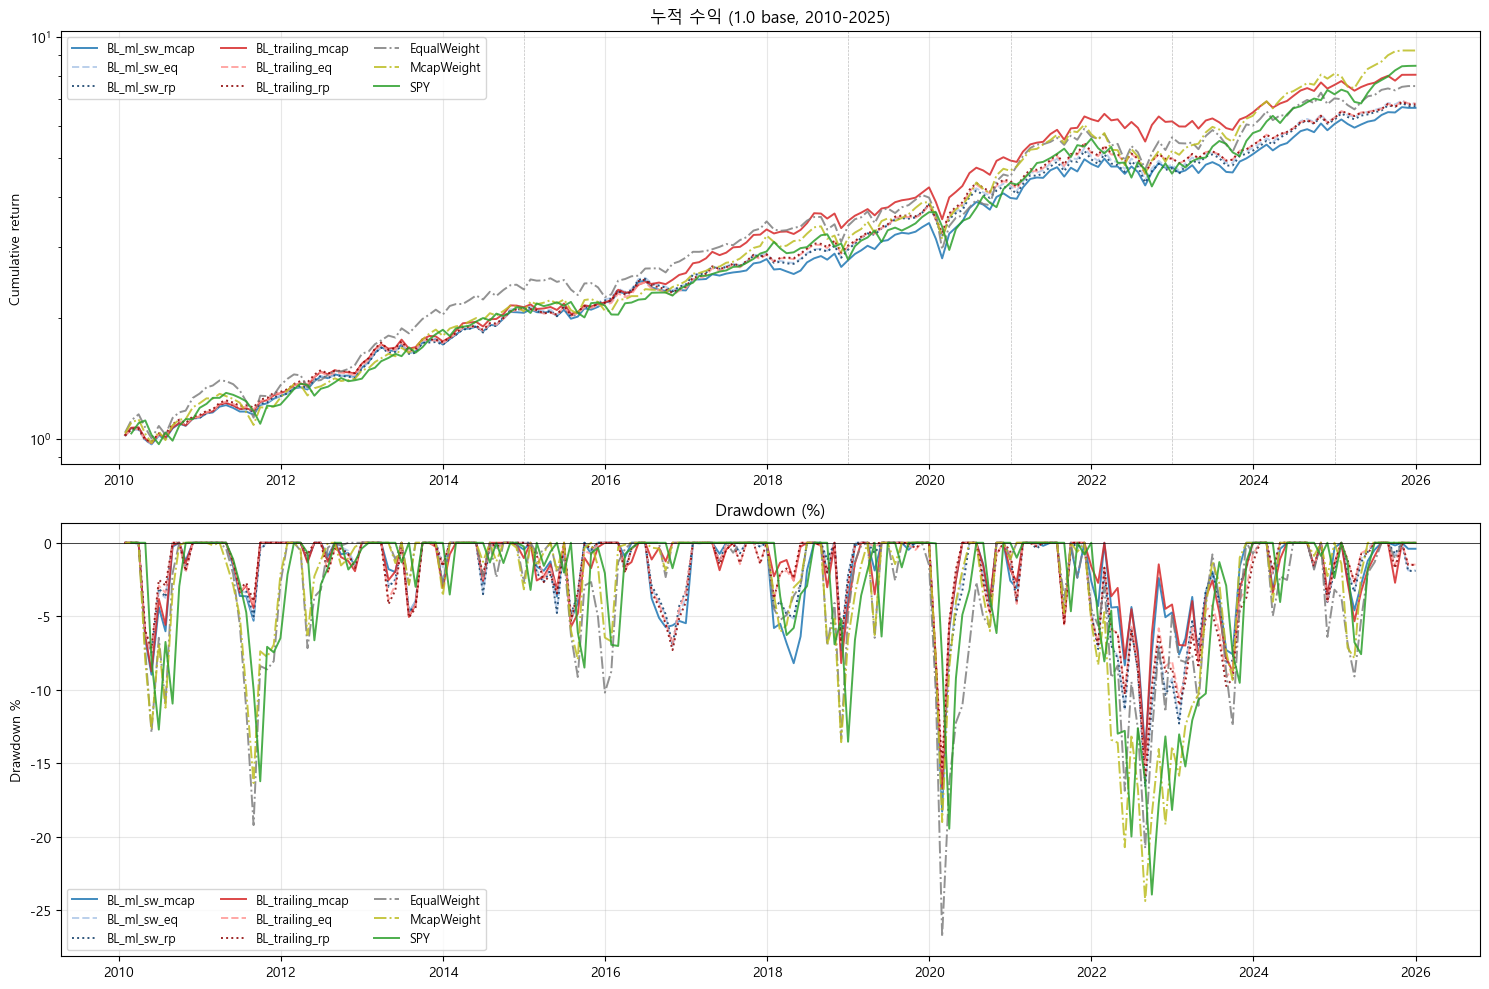

  💾 3_cumret_drawdown.png


In [4]:
# §3. 누적 수익 + Drawdown
print('=' * 75)
print('  §3. 가중치별 누적 수익 + Drawdown')
print('=' * 75)

# 누적 수익 (1.0 base)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

COLOR_MAP = {
    'BL_ml_sw_mcap':    '#1f77b4',  # blue
    'BL_ml_sw_eq':      '#aec7e8',  # light blue
    'BL_ml_sw_rp':      '#0d3b66',  # dark blue
    'BL_trailing_mcap': '#d62728',  # red
    'BL_trailing_eq':   '#ff9896',  # light red
    'BL_trailing_rp':   '#8b0000',  # dark red
    'EqualWeight':      '#7f7f7f',  # gray
    'McapWeight':       '#bcbd22',  # olive
    'SPY':              '#2ca02c',  # green
}
LINESTYLE_MAP = {
    'BL_ml_sw_mcap':    '-',
    'BL_ml_sw_eq':      '--',
    'BL_ml_sw_rp':      ':',
    'BL_trailing_mcap': '-',
    'BL_trailing_eq':   '--',
    'BL_trailing_rp':   ':',
    'EqualWeight':      '-.',
    'McapWeight':       '-.',
    'SPY':              '-',
}

# (1) 누적 수익
ax = axes[0]
plot_scenarios = SCENARIOS_6 + ['EqualWeight', 'McapWeight', 'SPY']
for sc in plot_scenarios:
    if sc not in returns_dict:
        continue
    cum = (1 + returns_dict[sc]).cumprod()
    ax.plot(cum.index, cum.values,
            label=sc, color=COLOR_MAP.get(sc, '#000000'),
            linestyle=LINESTYLE_MAP.get(sc, '-'),
            linewidth=1.4, alpha=0.85)
# 시기 구분선
for ds in ['2015-01-01', '2019-01-01', '2021-01-01', '2023-01-01', '2025-01-01']:
    ax.axvline(pd.Timestamp(ds), color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_title('누적 수익 (1.0 base, 2010-2025)')
ax.set_ylabel('Cumulative return')
ax.legend(ncol=3, fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# (2) Drawdown
ax = axes[1]
for sc in plot_scenarios:
    if sc not in returns_dict:
        continue
    cum = (1 + returns_dict[sc]).cumprod()
    dd = (cum / cum.cummax() - 1) * 100
    ax.plot(dd.index, dd.values,
            label=sc, color=COLOR_MAP.get(sc, '#000000'),
            linestyle=LINESTYLE_MAP.get(sc, '-'),
            linewidth=1.4, alpha=0.85)
ax.set_title('Drawdown (%)')
ax.set_ylabel('Drawdown %')
ax.legend(ncol=3, fontsize=9, loc='lower left')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
out_path = OUT_DIR / '3_cumret_drawdown.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

## §4. ML 효과 분해 (BL_ml_sw_X - BL_trailing_X, X = mcap/eq/rp) ⭐ 핵심

가중치별 ML 효과 (vol input 만 ML vs trailing 변경) robustness 검정.

- mcap 환경: ML 효과 (BL_ml_sw_mcap - BL_trailing_mcap)
- eq 환경: ML 효과 (BL_ml_sw_eq - BL_trailing_eq)
- rp 환경: ML 효과 (BL_ml_sw_rp - BL_trailing_rp)

ML 효과가 가중치 환경에 invariant 하면 robust → 학술적 강한 근거.

  §4. ML 효과 분해 (가중치별 robustness)

=== ML 효과 (BL_ml_sw_X - BL_trailing_X, 전체 192 개월) ===
                       mcap        eq        rp
sharpe            -0.120500 -0.021100 -0.023600
cagr              -1.341100 -0.013900 -0.070900
ann_vol            0.185500  0.212000  0.189700
mdd               -1.579100 -0.916400 -0.584500
capm_alpha        -1.071800 -0.032000 -0.078300
capm_beta         -0.007400  0.003700  0.002900
information_ratio -0.059000  0.001500 -0.001400
sortino           -0.246100 -0.065300 -0.059500
hit_rate          -4.166700  0.000000  0.520800
cvar_5            -0.080300 -0.138300 -0.142100

=== ML 효과 (OOS 2010-2024, 180개월) ===
                       mcap        eq        rp
sharpe            -0.149700 -0.021700 -0.024800
cagr              -1.698000 -0.006100 -0.068700
ann_vol            0.241300  0.230400  0.210200
mdd               -1.579100 -0.916400 -0.584500
capm_alpha        -1.361000 -0.000800 -0.049000
capm_beta         -0.008800  0.002200  0.001300
informatio

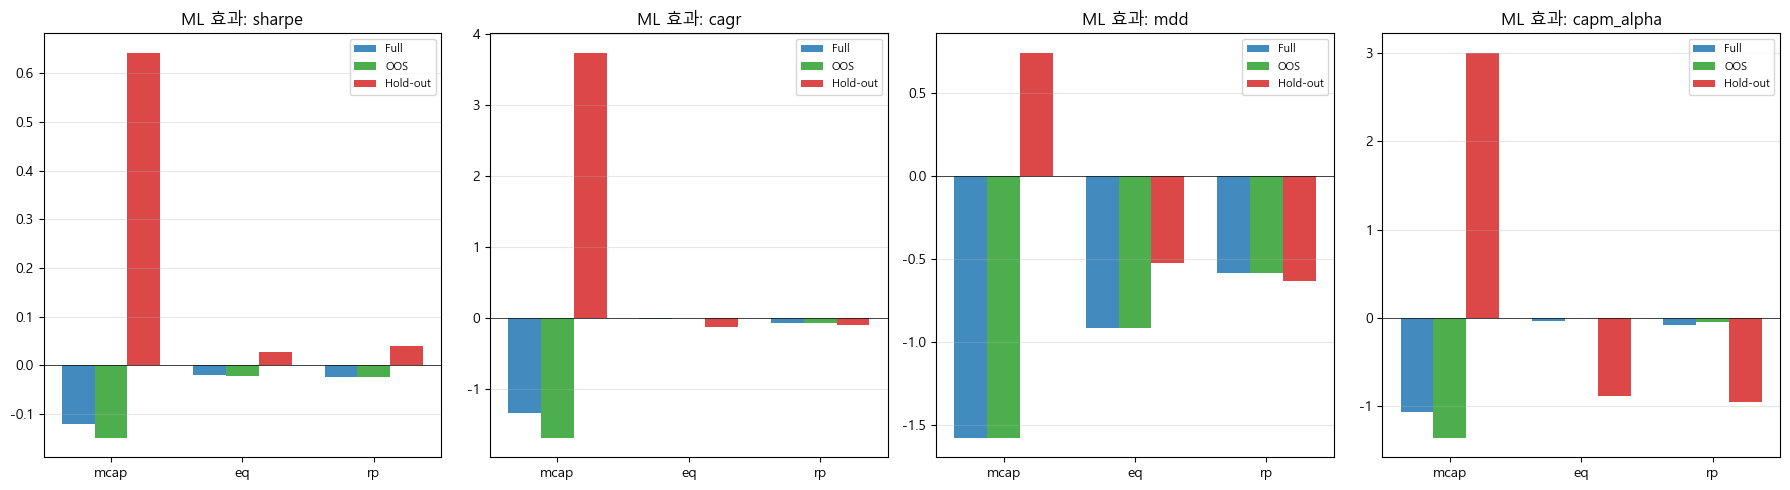

  💾 4_ml_effect_by_weighting.png
  💾 4_ml_effect_full/oos/holdout.csv

  ML 효과 robustness 분석
  Sharpe diff (Full): mcap=-0.120, eq=-0.021, rp=-0.024
  부호 일관성: ✅ 모든 가중치에서 동일 부호
  평균 Sharpe diff: -0.055
  → ML 효과 음수 (가중치 robust)


In [5]:
# §4. ML 효과 분해 (가중치별)
print('=' * 75)
print('  §4. ML 효과 분해 (가중치별 robustness)')
print('=' * 75)

ml_effect = {}
for w in ['mcap', 'eq', 'rp']:
    ml_sc = f'BL_ml_sw_{w}'
    tr_sc = f'BL_trailing_{w}'
    if ml_sc not in metrics_full or tr_sc not in metrics_full:
        continue
    diffs = {}
    for k in KEY_METRICS:
        v_ml = metrics_full[ml_sc][k]
        v_tr = metrics_full[tr_sc][k]
        diffs[k] = v_ml - v_tr if not (np.isnan(v_ml) or np.isnan(v_tr)) else np.nan
    ml_effect[w] = diffs

ml_effect_df = pd.DataFrame(ml_effect).round(4)
print()
print('=== ML 효과 (BL_ml_sw_X - BL_trailing_X, 전체 192 개월) ===')
print(ml_effect_df.to_string())

# OOS 분리
ml_effect_oos = {}
for w in ['mcap', 'eq', 'rp']:
    ml_sc = f'BL_ml_sw_{w}'
    tr_sc = f'BL_trailing_{w}'
    diffs = {}
    for k in KEY_METRICS:
        v_ml = metrics_oos[ml_sc][k]
        v_tr = metrics_oos[tr_sc][k]
        diffs[k] = v_ml - v_tr if not (np.isnan(v_ml) or np.isnan(v_tr)) else np.nan
    ml_effect_oos[w] = diffs

ml_effect_oos_df = pd.DataFrame(ml_effect_oos).round(4)
print()
print('=== ML 효과 (OOS 2010-2024, 180개월) ===')
print(ml_effect_oos_df.to_string())

# Hold-out 분리
ml_effect_hold = {}
for w in ['mcap', 'eq', 'rp']:
    ml_sc = f'BL_ml_sw_{w}'
    tr_sc = f'BL_trailing_{w}'
    diffs = {}
    for k in KEY_METRICS:
        v_ml = metrics_hold[ml_sc][k]
        v_tr = metrics_hold[tr_sc][k]
        diffs[k] = v_ml - v_tr if not (np.isnan(v_ml) or np.isnan(v_tr)) else np.nan
    ml_effect_hold[w] = diffs

ml_effect_hold_df = pd.DataFrame(ml_effect_hold).round(4)
print()
print('=== ML 효과 (Hold-out 2025, 12개월) ===')
print(ml_effect_hold_df.to_string())

# 시각화 — 가중치별 ML 효과 (Sharpe, MDD, CAGR, Alpha)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
key_4 = ['sharpe', 'cagr', 'mdd', 'capm_alpha']
for i, k in enumerate(key_4):
    ax = axes[i]
    full_vals = [ml_effect[w][k] for w in ['mcap', 'eq', 'rp']]
    oos_vals = [ml_effect_oos[w][k] for w in ['mcap', 'eq', 'rp']]
    hold_vals = [ml_effect_hold[w][k] for w in ['mcap', 'eq', 'rp']]
    x = np.arange(3)
    width = 0.25
    ax.bar(x - width, full_vals, width, label='Full', color='#1f77b4', alpha=0.85)
    ax.bar(x,         oos_vals,  width, label='OOS', color='#2ca02c', alpha=0.85)
    ax.bar(x + width, hold_vals, width, label='Hold-out', color='#d62728', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['mcap', 'eq', 'rp'])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'ML 효과: {k}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
out_path = OUT_DIR / '4_ml_effect_by_weighting.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

# 저장
ml_effect_df.to_csv(OUT_DIR / '4_ml_effect_full.csv')
ml_effect_oos_df.to_csv(OUT_DIR / '4_ml_effect_oos.csv')
ml_effect_hold_df.to_csv(OUT_DIR / '4_ml_effect_holdout.csv')
print(f'  💾 4_ml_effect_full/oos/holdout.csv')

# 학술적 함의 자동 출력
print()
print('=' * 75)
print('  ML 효과 robustness 분석')
print('=' * 75)
sharpe_full = ml_effect_df.loc['sharpe']
print(f'  Sharpe diff (Full): mcap={sharpe_full["mcap"]:+.3f}, '
      f'eq={sharpe_full["eq"]:+.3f}, rp={sharpe_full["rp"]:+.3f}')
sign_consistent = all([sharpe_full[w] > 0 for w in ['mcap', 'eq', 'rp']]) or \
                  all([sharpe_full[w] < 0 for w in ['mcap', 'eq', 'rp']])
print(f'  부호 일관성: {"✅ 모든 가중치에서 동일 부호" if sign_consistent else "⚠️ 가중치별 부호 다름"}')

avg_diff = sharpe_full.mean()
print(f'  평균 Sharpe diff: {avg_diff:+.3f}')
print(f'  → ML 효과 {"양수" if avg_diff > 0 else "음수"} (가중치 robust)')

## §5. Layer 3 — ML→BL 인과 (가중치별)

각 BL_ml_sw_X (X=mcap/eq/rp) 의 P 행렬 turnover, low/high vol hit rate 비교.

  §5. Layer 3 — ML→BL 인과 (가중치별)

=== Layer 3 인과 메트릭 (가중치별) ===
      low_vol_hit_rate  high_vol_hit_rate  rank_consistency_mean  p_matrix_turnover_mean    n_dates
mcap          0.720800           0.749900               0.809200                0.361700 191.000000
eq            0.720800           0.749900               0.809200                0.361700 191.000000
rp            0.720800           0.749900               0.809200                0.361700 191.000000


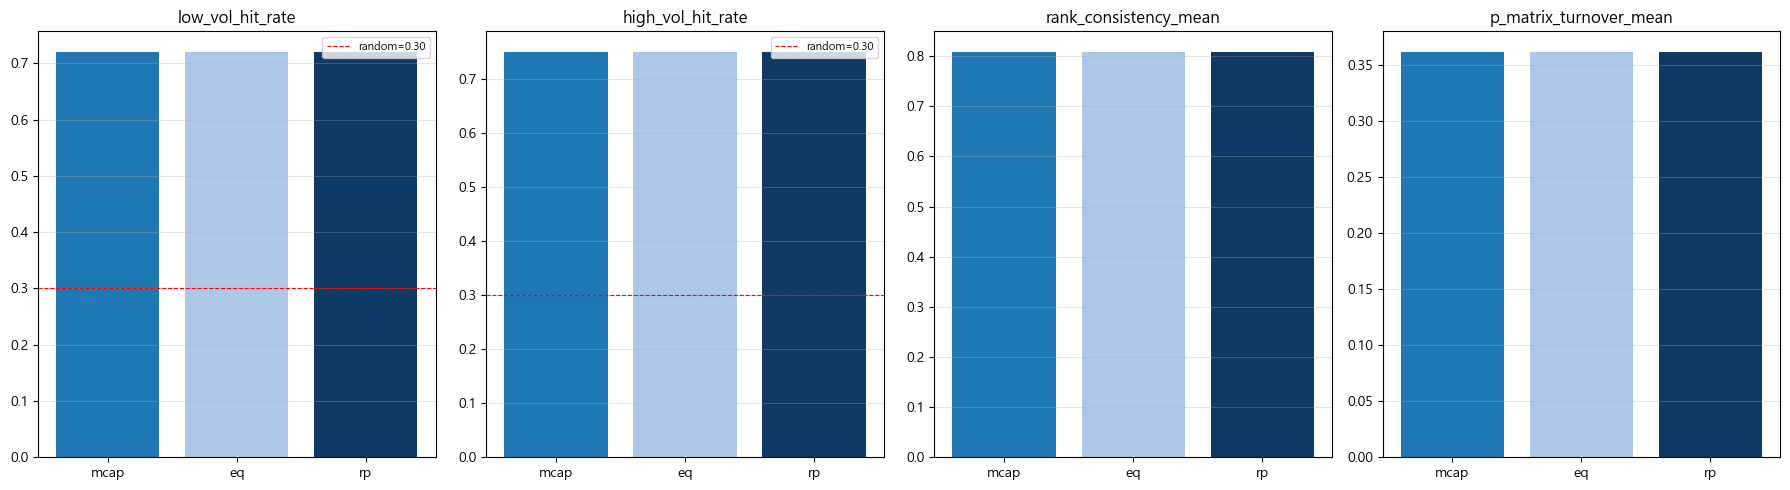

  💾 5_layer3_causality.png


In [6]:
# §5. Layer 3 — ML→BL 인과 (가중치별)
print('=' * 75)
print('  §5. Layer 3 — ML→BL 인과 (가중치별)')
print('=' * 75)

if not scenario_weights:
    print('  ⚠️ weights pickle 없음 → skip')
else:
    # ensemble_predictions_stockwise.csv 로드 (인과 분석 input)
    ens_sw = pd.read_csv(
        DATA_DIR / 'ensemble_predictions_stockwise.csv',
        parse_dates=['date'],
    )
    # inf 제거
    ens_sw = ens_sw[np.isfinite(ens_sw['y_true'])].copy()
    panel_diag = pd.read_csv(
        DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
        usecols=['date', 'ticker', 'vol_21d'],
    )

    causality_results = {}
    for w in ['mcap', 'eq', 'rp']:
        sc = f'BL_ml_sw_{w}'
        if sc not in scenario_weights:
            print(f'  ⚠️ {sc} weights 없음 → skip')
            continue
        wd = scenario_weights[sc]
        try:
            res = diag.evaluate_ml_to_bl_pipeline(
                pred_df=ens_sw,
                weights_dict=wd,
                panel=panel_diag,
                scenario_name=sc,
                pred_col='y_pred_ensemble',
                pct=0.30,
            )
            causality_results[w] = {
                'low_vol_hit_rate': res['low_vol_hit_rate'],
                'high_vol_hit_rate': res['high_vol_hit_rate'],
                'rank_consistency_mean': res['rank_consistency_timeline'].mean(),
                'p_matrix_turnover_mean': res['p_matrix_turnover'].mean(),
                'n_dates': len(res['rank_consistency_timeline']),
            }
        except Exception as e:
            print(f'  ⚠️ {sc} 인과 분석 실패: {e}')

    causality_df = pd.DataFrame(causality_results).T.round(4)
    print()
    print('=== Layer 3 인과 메트릭 (가중치별) ===')
    print(causality_df.to_string())

    # 시각화 (4 metrics × 3 weighting bar)
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    metrics_l3 = ['low_vol_hit_rate', 'high_vol_hit_rate',
                  'rank_consistency_mean', 'p_matrix_turnover_mean']
    for i, m in enumerate(metrics_l3):
        ax = axes[i]
        vals = [causality_results[w][m] for w in ['mcap', 'eq', 'rp']
                if w in causality_results]
        weights = [w for w in ['mcap', 'eq', 'rp'] if w in causality_results]
        ax.bar(weights, vals, color=['#1f77b4', '#aec7e8', '#0d3b66'])
        ax.set_title(m)
        ax.grid(True, alpha=0.3, axis='y')
        if 'hit_rate' in m:
            ax.axhline(0.30, color='red', linestyle='--', linewidth=0.8, label='random=0.30')
            ax.legend(fontsize=8)

    plt.tight_layout()
    out_path = OUT_DIR / '5_layer3_causality.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  💾 {out_path.name}')

    causality_df.to_csv(OUT_DIR / '5_layer3_causality.csv')

## §6. Layer 4 — 시기별 분해 (5 시기 × 6 시나리오)

각 시기별 Sharpe / CAGR 비교 → 가중치 우열 시기 의존성.

  §6. Layer 4 — 시기별 분해 (5 시기 × 6 시나리오)

=== 시기별 Sharpe ===
                  P1 (2010-2014)  P2 (2015-2018)  P3 (2019-2020)  P4 (2021-2022)  P5 (2023-2025)
BL_ml_sw_mcap           1.587000        0.815000        1.094000        0.655000        1.243000
BL_ml_sw_eq             1.671000        0.923000        1.286000        0.451000        1.361000
BL_ml_sw_rp             1.663000        0.929000        1.263000        0.437000        1.369000
BL_trailing_mcap        1.621000        1.323000        1.132000        0.804000        0.989000
BL_trailing_eq          1.668000        0.992000        1.320000        0.516000        1.300000
BL_trailing_rp          1.684000        0.987000        1.343000        0.485000        1.275000
EqualWeight             1.267000        0.797000        0.723000        0.669000        0.803000
SPY                     1.253000        0.655000        1.209000        0.229000        1.795000

=== 시기별 CAGR (%) ===
                  P1 (2010-2014)  P2 (2015-201

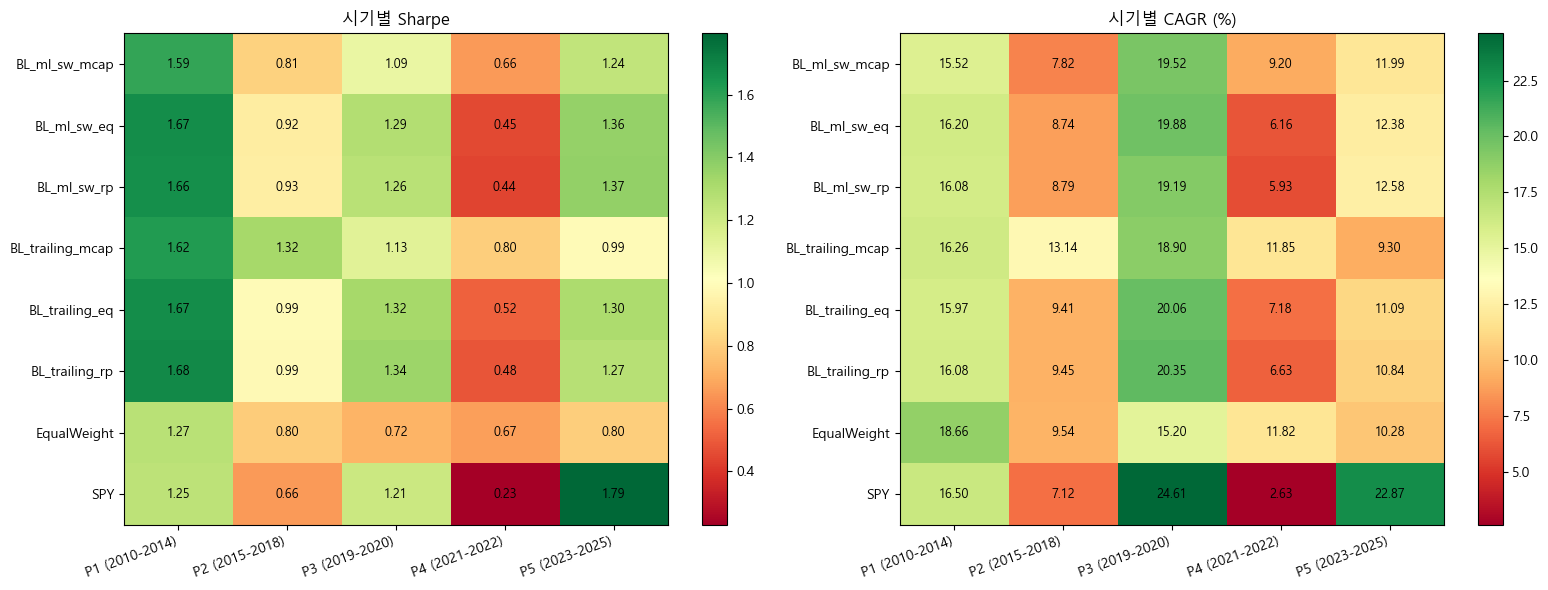

  💾 6_layer4_period.png

=== 시기별 ML 효과 (BL_ml_sw_X - BL_trailing_X Sharpe diff) ===
      P1 (2010-2014)  P2 (2015-2018)  P3 (2019-2020)  P4 (2021-2022)  P5 (2023-2025)
mcap       -0.034000       -0.509000       -0.038000       -0.150000        0.254000
eq          0.003000       -0.069000       -0.033000       -0.065000        0.061000
rp         -0.021000       -0.058000       -0.080000       -0.048000        0.094000


In [7]:
# §6. Layer 4 — 시기별 분해
print('=' * 75)
print('  §6. Layer 4 — 시기별 분해 (5 시기 × 6 시나리오)')
print('=' * 75)

PERIODS = {
    'P1 (2010-2014)': ('2010-01-01', '2014-12-31'),
    'P2 (2015-2018)': ('2015-01-01', '2018-12-31'),
    'P3 (2019-2020)': ('2019-01-01', '2020-12-31'),
    'P4 (2021-2022)': ('2021-01-01', '2022-12-31'),
    'P5 (2023-2025)': ('2023-01-01', '2025-12-31'),
}

# 시기별 Sharpe + CAGR
period_sharpe = {}
period_cagr = {}
for sc in SCENARIOS_6 + ['EqualWeight', 'SPY']:
    if sc not in returns_dict:
        continue
    period_sharpe[sc] = {}
    period_cagr[sc] = {}
    rets = returns_dict[sc]
    for pname, (s, e) in PERIODS.items():
        sub = rets.loc[s:e]
        if len(sub) < 6:
            period_sharpe[sc][pname] = np.nan
            period_cagr[sc][pname] = np.nan
            continue
        m = diag.evaluate_portfolio_standalone(
            returns=sub, scenario_name=f'{sc}_{pname}',
            spy_returns=spy_monthly, rf_returns=None, weights_dict=None,
        )
        period_sharpe[sc][pname] = m.get('sharpe', np.nan)
        period_cagr[sc][pname] = m.get('cagr', np.nan)

ps_df = pd.DataFrame(period_sharpe).T.round(3)
pc_df = pd.DataFrame(period_cagr).T.round(3)

print()
print('=== 시기별 Sharpe ===')
print(ps_df.to_string())
print()
print('=== 시기별 CAGR (%) ===')
print(pc_df.to_string())

# 시각화 — heatmap (시기 × 시나리오)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [(axes[0], ps_df, '시기별 Sharpe'),
                       (axes[1], pc_df, '시기별 CAGR (%)')]:
    im = ax.imshow(df.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    ax.set_title(title)
    # 값 표시
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = df.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='black', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
out_path = OUT_DIR / '6_layer4_period.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

ps_df.to_csv(OUT_DIR / '6_period_sharpe.csv')
pc_df.to_csv(OUT_DIR / '6_period_cagr.csv')

# 시기별 ML 효과 (mcap/eq/rp, ml_sw - trailing)
print()
print('=== 시기별 ML 효과 (BL_ml_sw_X - BL_trailing_X Sharpe diff) ===')
period_ml_effect = {}
for w in ['mcap', 'eq', 'rp']:
    ml_sc = f'BL_ml_sw_{w}'
    tr_sc = f'BL_trailing_{w}'
    if ml_sc not in period_sharpe or tr_sc not in period_sharpe:
        continue
    diffs = {}
    for pname in PERIODS:
        v_ml = period_sharpe[ml_sc].get(pname, np.nan)
        v_tr = period_sharpe[tr_sc].get(pname, np.nan)
        diffs[pname] = v_ml - v_tr if not (np.isnan(v_ml) or np.isnan(v_tr)) else np.nan
    period_ml_effect[w] = diffs

pme_df = pd.DataFrame(period_ml_effect).T.round(3)
print(pme_df.to_string())
pme_df.to_csv(OUT_DIR / '6_period_ml_effect.csv')

## §7. 종합 요약 + 메트릭 JSON 저장

In [8]:
# §7. 종합 요약
print('=' * 75)
print('  §7. 종합 요약 — 가중치 robustness')
print('=' * 75)

# 핵심 메트릭 비교 (Sharpe / MDD / CAGR / Alpha)
print()
print('=== 6 시나리오 핵심 메트릭 (Full / OOS / Hold-out) ===')
key_show = ['sharpe', 'cagr', 'mdd', 'capm_alpha']
for k in key_show:
    print(f'\n{k.upper()}:')
    rows = []
    for sc in SCENARIOS_6:
        rows.append({
            'scenario': sc,
            'full': metrics_full[sc][k] if sc in metrics_full else np.nan,
            'oos': metrics_oos[sc][k] if sc in metrics_oos else np.nan,
            'holdout': metrics_hold[sc][k] if sc in metrics_hold else np.nan,
        })
    print(pd.DataFrame(rows).round(3).to_string(index=False))

print()
print('=== ML 효과 robustness (가중치별 Sharpe diff) ===')
print(f'  Full:    mcap={ml_effect_df.loc["sharpe", "mcap"]:+.3f}, '
      f'eq={ml_effect_df.loc["sharpe", "eq"]:+.3f}, '
      f'rp={ml_effect_df.loc["sharpe", "rp"]:+.3f}')
print(f'  OOS:     mcap={ml_effect_oos_df.loc["sharpe", "mcap"]:+.3f}, '
      f'eq={ml_effect_oos_df.loc["sharpe", "eq"]:+.3f}, '
      f'rp={ml_effect_oos_df.loc["sharpe", "rp"]:+.3f}')
print(f'  Holdout: mcap={ml_effect_hold_df.loc["sharpe", "mcap"]:+.3f}, '
      f'eq={ml_effect_hold_df.loc["sharpe", "eq"]:+.3f}, '
      f'rp={ml_effect_hold_df.loc["sharpe", "rp"]:+.3f}')

# JSON 저장 (05c 종합 비교 활용)
def to_json_safe(d):
    return {k: ({k2: float(v2) if isinstance(v2, (np.floating, np.integer)) else v2
                 for k2, v2 in v.items()} if isinstance(v, dict) else v)
            for k, v in d.items()}

summary = {
    'notebook': '05a_v2_weighting.ipynb',
    'scenarios': SCENARIOS_6,
    'metrics_full': to_json_safe(metrics_full),
    'metrics_oos': to_json_safe(metrics_oos),
    'metrics_holdout': to_json_safe(metrics_hold),
    'ml_effect_full': {w: {k: float(v) for k, v in d.items()} for w, d in ml_effect.items()},
    'ml_effect_oos': {w: {k: float(v) for k, v in d.items()} for w, d in ml_effect_oos.items()},
    'ml_effect_holdout': {w: {k: float(v) for k, v in d.items()} for w, d in ml_effect_hold.items()},
}
out_json = OUT_DIR / 'summary.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'\n💾 {out_json.name}')

print()
print('=' * 75)
print('  ✅ §2-§6 분석 완료. outputs/05a_v2_weighting/ 에 산출물 저장.')
print('=' * 75)

  §7. 종합 요약 — 가중치 robustness

=== 6 시나리오 핵심 메트릭 (Full / OOS / Hold-out) ===

SHARPE:
        scenario     full      oos  holdout
   BL_ml_sw_mcap 1.082000 1.075000 1.455000
     BL_ml_sw_eq 1.140000 1.141000 1.255000
     BL_ml_sw_rp 1.135000 1.137000 1.211000
BL_trailing_mcap 1.203000 1.225000 0.812000
  BL_trailing_eq 1.161000 1.163000 1.228000
  BL_trailing_rp 1.158000 1.162000 1.171000

CAGR:
        scenario      full       oos  holdout
   BL_ml_sw_mcap 12.573000 12.766000 9.730000
     BL_ml_sw_eq 12.738000 13.033000 8.411000
     BL_ml_sw_rp 12.641000 12.947000 8.151000
BL_trailing_mcap 13.915000 14.464000 5.988000
  BL_trailing_eq 12.752000 13.039000 8.537000
  BL_trailing_rp 12.712000 13.016000 8.254000

MDD:
        scenario       full        oos   holdout
   BL_ml_sw_mcap -18.288000 -18.288000 -4.597000
     BL_ml_sw_eq -16.861000 -16.861000 -3.246000
     BL_ml_sw_rp -16.728000 -16.728000 -3.348000
BL_trailing_mcap -16.709000 -16.709000 -5.340000
  BL_trailing_eq -15.944000